# **Chương 7: Các phương pháp tính gần đúng**

# Phương pháp Euler

In [ ]:
from math import *
import numpy as np
from prettytable import PrettyTable
import matplotlib.pyplot as plt

def f(x):
    return np.round(np.sqrt(2*x + 1), 5)

def df(x, y):
    return y - 2*x/y

In [ ]:
## Ví dụ 1
x = [0]
y = [1]
dy = [df(x[-1], y[-1])] # đạo hàm tại (xi,yi)
half_dy = [] # giá trị df_i+1/2
half_y = [] # y_i+1/2
half_x = [] # x_i+1/2
h = 0.2
it = 10
for i in range(it):
    half_x.append(x[-1] + h/2)
    half_y.append(y[-1] + h/2*dy[-1])
    half_dy.append(df(half_x[-1], half_y[-1]))
    x.append(x[-1] + h)
    y.append(y[-1] + h*half_dy[-1])
    dy.append(df(x[-1], y[-1]))

table = PrettyTable()
table.add_column("i", range(it))
table.add_column("x", np.round(x[:-1], 5))
table.add_column("y", np.round(y[:-1],5))
table.add_column("f_i", np.round(dy[:-1],5))
table.add_column("f_(i+1/2)", np.round(half_dy,5))
table.add_column("y_(i+1/2)", np.round(half_y, 5))
table.add_column("y_(i+1)", np.round(y[1:], 5))
table.add_column("f(x)", f(np.array(x[:-1])))
print(table)

+---+-----+---------+---------+-----------+-----------+---------+---------+
| i |  x  |    y    |   f_i   | f_(i+1/2) | y_(i+1/2) | y_(i+1) |   f(x)  |
+---+-----+---------+---------+-----------+-----------+---------+---------+
| 0 | 0.0 |   1.0   |   1.0   |  0.91818  |    1.1    | 1.18364 |   1.0   |
| 1 | 0.2 | 1.18364 | 0.84569 |   0.7951  |  1.26821  | 1.34266 | 1.18322 |
| 2 | 0.4 | 1.34266 | 0.74682 |  0.71179  |  1.41734  | 1.48501 | 1.34164 |
| 3 | 0.6 | 1.48501 | 0.67694 |  0.65106  |  1.55271  | 1.61522 | 1.48324 |
| 4 | 0.8 | 1.61522 | 0.62465 |  0.60479  |  1.67769  | 1.73618 | 1.61245 |
| 5 | 1.0 | 1.73618 | 0.58423 |  0.56871  |  1.79461  | 1.84992 | 1.73205 |
| 6 | 1.2 | 1.84992 | 0.55257 |  0.54048  |  1.90518  | 1.95802 | 1.84391 |
| 7 | 1.4 | 1.95802 |  0.528  |  0.51889  |  2.01082  |  2.0618 | 1.94936 |
| 8 | 1.6 |  2.0618 | 0.50976 |  0.50352  |  2.11277  |  2.1625 | 2.04939 |
| 9 | 1.8 |  2.1625 | 0.49776 |  0.49459  |  2.21228  | 2.26142 | 2.14476 |
+---+-----+-

x_n	    y_n
0.0 	 0.000000
0.25 	 0.000000
0.5 	 0.062500
0.75 	 0.218750
1.0 	 0.515625


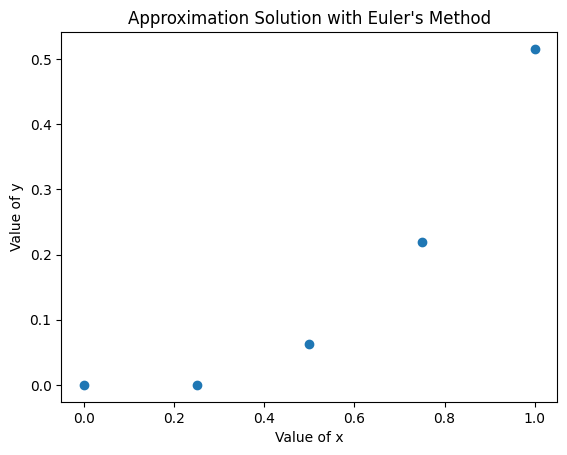

In [ ]:
x0 = 0
y0 = 0
xf = 1
n = 5
deltax = (xf-x0)/(n-1)
x = np.linspace(x0,xf,n)

def f(x,y):
	return x+2*y

y = np.zeros([n])
y[0] = y0

for i in range(1,n):
	y[i] = deltax*f(x[i-1],y0) + y0
	y0 = y[i]

print("x_n\t    y_n")
for i in range(n):
	print(x[i],"\t",format(y[i],'6f'))

plt.plot(x,y,'o')
plt.xlabel("Value of x")
plt.ylabel("Value of y")
plt.title("Approximation Solution with Euler's Method")
plt.show()

x_n	   py_n	           y_n
0.0 	    nan 	 2.000000
0.1 	 2.200000 	 2.205000
0.2 	 2.415500 	 2.421025
0.30000000000000004 	 2.643128 	 2.649233
0.4 	 2.884156 	 2.890902
0.5 	 3.139992 	 3.147447
0.6000000000000001 	 3.412191 	 3.420429
0.7000000000000001 	 3.702472 	 3.711574
0.8 	 4.012731 	 4.022789
0.9 	 4.345068 	 4.356182
1.0 	 4.701800 	 4.714081


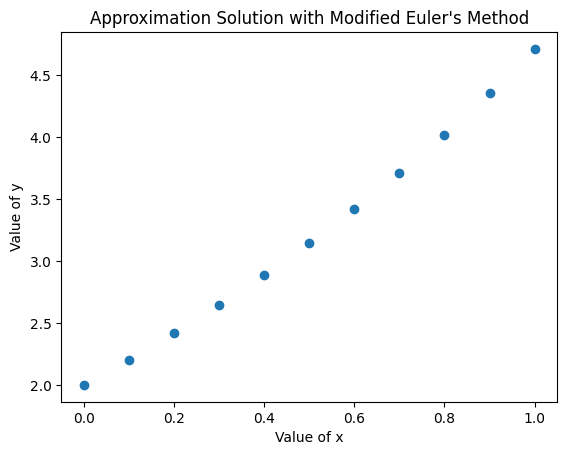

In [ ]:
## Ví dụ 3

x0 = 0
y0 = 2
xf = 1
n = 11
deltax = (xf-x0)/(n-1)
x = np.linspace(x0,xf,n)
def f(x,y):
	return y-x

y = np.zeros([n])
y[0] = y0
py = np.zeros([n])
py[0] = None

for i in range(1,n):
	py[i] = deltax*f(x[i-1],y[i-1]) + y[i-1]
	y[i] = deltax/2*( f(x[i],py[i]) + f(x[i-1],y[i-1]) ) + y[i-1]
print("x_n\t   py_n\t           y_n")
for i in range(n):
	print (x[i],"\t",format(py[i],'6f'),"\t",format(y[i],'6f'))

plt.plot(x,y,'o')
plt.xlabel("Value of x")
plt.ylabel("Value of y")
plt.title("Approximation Solution with Modified Euler's Method")
plt.show()

# Phương pháp Rough-Kutta bậc 4

In [ ]:
def f(x):
    return np.round(1/5*x*np.exp(3*x) - 1/25*np.exp(3*x) + 1/25*np.exp(-2*x), 5)

def dy(x, y):
    return x*exp(3*x) - 2*y

In [ ]:
y = [0] # khai báo y0
x = [0]
h = 0.1
it = 10 # số vòng lặp

k1 = []
k2 = []
k3 = []
k4 = []
delta_y = []

In [ ]:
for i in range(it):
    ki_1 =  h*dy(x[-1], y[-1])
    ki_2 = h*dy(x[-1] + h/2, y[-1] + ki_1/2)
    ki_3 = h*dy(x[-1] + h/2, y[-1] + ki_2/2)
    ki_4 = h*dy(x[-1] + h, y[-1] + ki_3)

    delta_yi = 1/6*(ki_1 + 2*ki_2 + 2*ki_3 + ki_4)

    k1 = np.append(k1, ki_1)
    k2 = np.append(k2, ki_2)
    k3 = np.append(k3, ki_3)
    k4 = np.append(k4, ki_4)
    delta_y = np.append(delta_y, delta_yi)

    y = np.append(y, y[-1] + delta_yi)
    x = np.append(x, x[-1] + h)


In [ ]:
x = np.round(x,3)
y = np.round(y, 5)
k1 = np.round(k1, 5)
k2 = np.round(k2, 5)
k3 = np.round(k3, 5)
k4 = np.round(k4, 5)
delta_y = np.round(delta_y, 5)

In [ ]:
dat_dtype = {
    'names' : ("x", "y", "k1", "k2", "k3", "k4", "delta_y", "y_i+1"),
    'formats' : ("float", "float", "float",  "float",  "float", "float",  "float",  "float")}

table = PrettyTable()
table.add_column("x", x[:-1])
table.add_column("y", y[:-1])
table.add_column("k1", k1)
table.add_column("k2", k2)
table.add_column("k3", k3)
table.add_column("k4", k4)
table.add_column("delta_y", delta_y)
table.add_column("y_i+1", y[1:])

print(table)

+-----+---------+---------+---------+---------+---------+---------+---------+
|  x  |    y    |    k1   |    k2   |    k3   |    k4   | delta_y |  y_i+1  |
+-----+---------+---------+---------+---------+---------+---------+---------+
| 0.0 |   0.0   |   0.0   | 0.00581 | 0.00523 | 0.01245 | 0.00575 | 0.00575 |
| 0.1 | 0.00575 | 0.01235 | 0.02114 | 0.02026 | 0.03124 | 0.02106 | 0.02682 |
| 0.2 | 0.02682 | 0.03108 | 0.04445 | 0.04312 |  0.0598 | 0.04434 | 0.07116 |
| 0.3 | 0.07116 | 0.05956 | 0.07983 |  0.0778 | 0.10301 | 0.07964 |  0.1508 |
| 0.4 |  0.1508 | 0.10265 | 0.13316 | 0.13011 |  0.1679 | 0.13285 | 0.28364 |
| 0.5 | 0.28364 | 0.16736 | 0.21292 | 0.20836 | 0.26458 | 0.21242 | 0.49606 |
| 0.6 | 0.49606 | 0.26377 | 0.33128 | 0.32453 | 0.40751 | 0.33048 | 0.82654 |
| 0.7 | 0.82654 | 0.40632 | 0.50564 | 0.49571 |  0.6174 |  0.5044 | 1.33094 |
| 0.8 | 1.33094 | 0.61567 | 0.76085 | 0.74633 | 0.92372 | 0.75896 |  2.0899 |
| 0.9 |  2.0899 |  0.9212 | 1.13224 | 1.11114 | 1.36835 | 1.1293

# Phương pháp Heun

In [15]:
def f(x):
    return np.round(np.sqrt(2*x + 1), 5)
def df(x, y):
    return y - 2*x/y

In [16]:
x = [0]
y = [1]
dy = [df(x[-1], y[-1])]
h = 0.2
y_tmp = [] # giá trị tham số trung gian y_i+1 = yi + h*df(xi,yi)
dy_tmp = [] # giá trị tham số trung gian dy(x_i+1, y_tmp[-1])
it = 10
for i in range(it):
    y_tmp.append(y[-1] + h*dy[-1])
    x.append(x[-1] + h)
    dy_tmp.append(df(x[-1], y_tmp[-1]))
    y.append(y[-1] + h*(dy[-1] + dy_tmp[-1])/2)
    dy.append(df(x[-1], y[-1]))

In [17]:
table = PrettyTable()
table.add_column("i", range(it))
table.add_column("x", np.round(x[:-1], 5))
table.add_column("y", np.round(y[:-1],5))
table.add_column("dy(xi,yi)", np.round(dy[:-1],5))
table.add_column("y_tmp(i+1)", np.round(y_tmp,5))
table.add_column("dy_tmp(x(i+1),y_tmp(i+1))", np.round(dy_tmp,5))
table.add_column("y_(i+1)", np.round(y[1:], 5))
table.add_column("f(x)", f(np.array(x[:-1])))

print(table)

+---+-----+---------+-----------+------------+---------------------------+---------+---------+
| i |  x  |    y    | dy(xi,yi) | y_tmp(i+1) | dy_tmp(x(i+1),y_tmp(i+1)) | y_(i+1) |   f(x)  |
+---+-----+---------+-----------+------------+---------------------------+---------+---------+
| 0 | 0.0 |   1.0   |    1.0    |    1.2     |          0.86667          | 1.18667 |   1.0   |
| 1 | 0.2 | 1.18667 |  0.84959  |  1.35658   |          0.76687          | 1.34831 | 1.18322 |
| 2 | 0.4 | 1.34831 |  0.75498  |  1.49931   |          0.69894          |  1.4937 | 1.34164 |
| 3 | 0.6 |  1.4937 |  0.69033  |  1.63177   |          0.65124          | 1.62786 | 1.48324 |
| 4 | 0.8 | 1.62786 |  0.64498  |  1.75686   |          0.61846          |  1.7542 | 1.61245 |
| 5 | 1.0 |  1.7542 |  0.61409  |  1.87702   |           0.5984          | 1.87545 | 1.73205 |
| 6 | 1.2 | 1.87545 |  0.59576  |  1.99461   |          0.59082          | 1.99411 | 1.84391 |
| 7 | 1.4 | 1.99411 |  0.58998  |  2.11211   |    